# 07 — Summary

The portfolio-piece headline notebook. Single-screen, no exploration —
just the things a structured-products desk would ask to see for a
hypothetical worst-of FCN on AMZN, META and MU:

1. **Final price** with antithetic + worst-of put CV stacked, plus the
   single-asset PDE cross-validation row.
2. **Greeks table** (Δ, Γ, vega, ρ_pair) — bump-and-revalue with CRN.
3. **Honest findings** — two plots that show where this implementation
   works well and where it doesn't.
4. **Limitations** — flat-vol, constant-correlation, European KI, fair
   summary of what's *not* in the model.

This notebook is intentionally short and reads top-to-bottom. The
preceding notebooks (`01`–`06`) are the working ones.

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.market_data import load_market_data, MarketData
from src.fcn_payoff import FCNProduct
from src.mc_pricer import price_fcn
from src.pde_pricer import price_fcn_pde_1d
from src.greeks import mc_greeks_bump, pde_greeks_1d, mc_delta_curve, pde_delta_curve

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## Setup

JT-spec'd AMZN/META/MU FCN, 1Y nominal tenor (~199 calendar days from
issue to maturity), 8% p.a. coupon paid in 6 sub-periods, autocall at
100% (5 observation dates), European KI at 70%.

In [2]:
ISSUE_DATE = date(2025, 10, 17)
TICKERS = ("AMZN", "META", "MU")
market = load_market_data(tickers=TICKERS, lookback_years=5, target_T=0.5, as_of=ISSUE_DATE)
product = FCNProduct(
    notional=50_000.0,
    coupon_rate=0.01535,
    obs_dates=(
        date(2025, 12, 1),
        date(2025, 12, 31),
        date(2026, 2, 2),
        date(2026, 3, 2),
        date(2026, 3, 31),
        date(2026, 4, 30),
    ),
    pay_dates=(
        date(2025, 12, 3),
        date(2026, 1, 5),
        date(2026, 2, 4),
        date(2026, 3, 4),
        date(2026, 4, 2),
        date(2026, 5, 4),
    ),
    issue_date=ISSUE_DATE,
    autocall_barrier=1.00,
    strike=0.70,
    n_autocall_obs=5,
    coupon_barrier=None,
    geared_downside=False,
    continuous_ki=False,
)
print(market.summary())


MarketData snapshot as of 2026-05-11T01:38:18.836245+00:00
Tickers      : ['AMZN', 'META', 'MU']
Spots        : {'AMZN': np.float64(213.04), 'META': np.float64(715.723), 'MU': np.float64(202.2133)}
Vols (ann.)  : {'AMZN': np.float64(0.3502), 'META': np.float64(0.4397), 'MU': np.float64(0.4713)}
Div yields   : {'AMZN': np.float64(0.0), 'META': np.float64(0.0029), 'MU': np.float64(0.00227)}
Risk-free 1Y : 0.03819
Correlation matrix:
       AMZN   META     MU
AMZN 1.0000 0.6139 0.4422
META 0.6139 1.0000 0.4176
MU   0.4422 0.4176 1.0000
Sources:
  as_of: 2025-10-17
  spots: yfinance daily closes (last bar on or before 2025-10-17)
  history: yfinance 5Y daily closes ending 2025-10-17
  realised_vols: log-return std × √252
  implied_vols: AMZN: realised 5Y vol (0.3502) @ 2025-10-17; META: realised 5Y vol (0.4397) @ 2025-10-17; MU: realised 5Y vol (0.4713) @ 2025-10-17
  dividends: AMZN: hardcoded fallback (0.0000); META: trailing 12M dividends / spot @ 2025-10-17 (0.0029); MU: trailing 12M d

## 1. Price

Antithetic variates and the worst-of-put control variate are stacked. The
main MC run uses 80,000 antithetic paths (= 160k effective) with seed
pinned. $\mathbb{E}[Y]$ for the CV comes from an independent 400k-path
pre-pass.

In [3]:
final_mc = price_fcn(
    market=market, product=product, n_paths=80_000, antithetic=True,
    seed=20260601, control_variate='worst_of_put', cv_n_paths_for_ey=400_000,
)
print(final_mc.summary())


FCN price : 47,063.9365  (= 94.1279% of notional)
MC SE     : 11.7385  (0.025% of price)
Paths     : 160,000

Probability decomposition:
  P(first autocall = period 1) = 0.2329
  P(first autocall = period 2) = 0.0861
  P(first autocall = period 3) = 0.0548
  P(first autocall = period 4) = 0.0352
  P(first autocall = period 5) = 0.0277
  P(autocall total)             = 0.4367
  P(KI at maturity, no AC)      = 0.2649
  P(alive, no KI, no AC)        = 0.2984

Control variate (worst-of European put):
  β̂           : -2.1393   (corr(X, Y) = -0.8424)
  Ê[Y]        : 1,704.7619 ± 3.8255  (pre-pass n = 800,000)
  Price w/o CV: 47,042.6490 ± 21.7815
  Price w/  CV: 47,063.9365 ± 11.7385
  Var(X) / Var(X_cv): 3.44×   (SE ratio: 1.86×)

Diagnostics:
  tickers: ['AMZN', 'META', 'MU']
  as_of: 2025-10-17
  rate: 0.03819 (yfinance interpolated ^IRX/^FVX -> 0.50Y (as_of 2025-10-17))
  vols: {'AMZN': 0.3502, 'META': 0.4397, 'MU': 0.4713}
  divs: {'AMZN': 0.0, 'META': 0.0029, 'MU': 0.00227}
  spots: {

### Single-asset PDE cross-validation

The 1D Crank–Nicolson PDE prices the same product applied to each name
individually (worst-of operator dropped). All three lie inside a few MC
standard errors of the MC price — independent confirmation that the
path-engine and payoff arithmetic are wired up correctly.

In [4]:
rows = []
for i, name in enumerate(TICKERS):
    mkt_i = MarketData(
        tickers=[name],
        spots=np.array([market.spots[i]], dtype=float),
        vols=np.array([market.vols[i]], dtype=float),
        divs=np.array([market.divs[i]], dtype=float),
        corr=np.array([[1.0]]), rate=market.rate,
        history=pd.DataFrame(), sources={'as_of': 'reduction'},
    )
    mc_i = price_fcn(market=mkt_i, product=product, n_paths=80_000, antithetic=True, seed=20260511)
    pde_i = price_fcn_pde_1d(
        spot=float(mkt_i.spots[0]), vol=float(mkt_i.vols[0]),
        div=float(mkt_i.divs[0]), rate=mkt_i.rate, product=product,
        n_space=1600, n_time_per_period=160,
    )
    rows.append({
        'reduction': name,
        'spot': float(mkt_i.spots[0]),
        'vol': float(mkt_i.vols[0]),
        'MC price': mc_i.price, 'MC SE': mc_i.standard_error,
        'PDE price': pde_i.price,
        '|Δ| / SE': abs(pde_i.price - mc_i.price) / max(mc_i.standard_error, 1e-12),
    })
pd.DataFrame(rows).round(4)


,reduction,spot,vol,MC price,MC SE,PDE price,|Δ| / SE
0,AMZN,213.0400,0.3502,"50,279.5320",11.2800,"50,273.4181",0.5420
1,META,715.7230,0.4397,"49,265.4996",15.2314,"49,266.8242",0.0870
2,MU,202.2133,0.4713,"48,908.3359",16.4616,"48,911.7411",0.2069


## 2. Greeks

Bump-and-revalue with CRN at 80k antithetic paths, 1% spot bump, 1 vol-pt
vega bump, 0.05 correlation bump (reported per 0.01).

In [5]:
greeks = mc_greeks_bump(
    market=market, product=product, n_paths=80_000, antithetic=True,
    seed=20260512, spot_bump_rel=0.01, vol_bump_abs=0.01, corr_bump_abs=0.05,
)
se = greeks.standard_errors
rows = []
spots = np.array(market.spots)
for i, name in enumerate(TICKERS):
    rows.append({
        'asset': name, 'spot': spots[i],
        'Δ_per_1%': greeks.delta_pct[i], 'Δ SE_per_1%': se['delta'][i] * spots[i] / 100,
        'Γ_per_1%×1%': greeks.gamma_pct[i],
        'vega/volpt': greeks.vega_per_volpt[i], 'vega SE/volpt': se['vega'][i] / 100,
    })
pd.DataFrame(rows).round(4)


,asset,spot,Δ_per_1%,Δ SE_per_1%,Γ_per_1%×1%,vega/volpt,vega SE/volpt
0,AMZN,213.0400,47.8185,1.7624,0.2576,-54.9210,1.3931
1,META,715.7230,86.5914,1.9835,-7.3832,-88.9275,1.5839
2,MU,202.2133,106.1817,2.1655,-0.6644,-102.6009,1.6721


In [6]:
rho_rows = []
for i in range(3):
    for j in range(i+1, 3):
        rho_rows.append({
            'pair': f"{TICKERS[i]}–{TICKERS[j]}",
            'ρ_base': market.corr[i, j],
            '∂V/∂ρ per 0.01': greeks.rho_pair[i, j] / 100,
            'SE per 0.01': se['rho_pair'][i, j] / 100,
        })
pd.DataFrame(rho_rows).round(4)


,pair,ρ_base,∂V/∂ρ per 0.01,SE per 0.01
0,AMZN–META,0.6139,7.3839,0.5282
1,AMZN–MU,0.4422,4.9555,0.5086
2,META–MU,0.4176,11.9113,0.4954


## 3. Honest findings

Two plots, each worth more than a sentence.

### 3.1 Δ near the barriers — MC noise vs the PDE smooth reference

Bump-and-revalue MC Greeks are noisy near the discrete-observation
barriers. The mechanism is well-known (Glasserman 2003, §7.2):
near `S/S₀ = 1.00` and `S/S₀ = 0.70`, the bump occasionally flips a
path's outcome between two qualitatively different regimes (autocall
vs continue; KI vs above-strike), creating a discontinuous payoff
difference that the variance estimator cannot smooth over. We see
this in the widening of the MC ribbon precisely at those two
levels.

In [7]:
amzn_market = MarketData(
    tickers=['AMZN'],
    spots=np.array([market.spots[0]], dtype=float),
    vols=np.array([market.vols[0]], dtype=float),
    divs=np.array([market.divs[0]], dtype=float),
    corr=np.array([[1.0]]), rate=market.rate,
    history=pd.DataFrame(), sources={'as_of': 'plot'},
)
spot_anchor = float(amzn_market.spots[0])
spot_grid = np.linspace(0.4 * spot_anchor, 1.3 * spot_anchor, 41)
mc_delta, mc_delta_se = mc_delta_curve(
    market=amzn_market, product=product, spot_grid=spot_grid, asset_index=0,
    n_paths=20_000, antithetic=True, seed=20260513, spot_bump_rel=0.01,
)
pde_delta = pde_delta_curve(
    vol=float(amzn_market.vols[0]), div=float(amzn_market.divs[0]), rate=amzn_market.rate,
    product=product, spot_grid=spot_grid,
    n_space=1200, n_time_per_period=120,
)


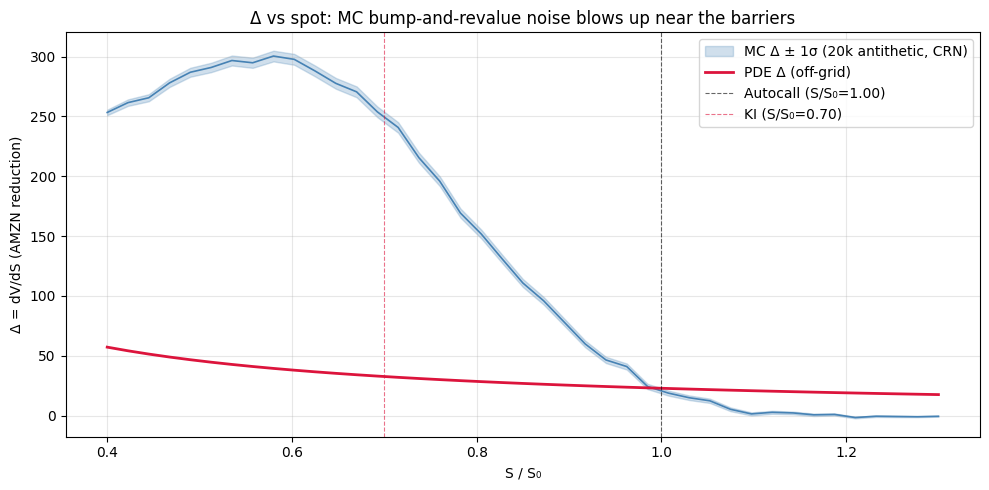

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
perf = spot_grid / spot_anchor
ax.fill_between(perf, mc_delta - mc_delta_se, mc_delta + mc_delta_se, alpha=0.25, color='steelblue', label='MC Δ ± 1σ (20k antithetic, CRN)')
ax.plot(perf, mc_delta, color='steelblue', lw=1.2)
ax.plot(perf, pde_delta, color='crimson', lw=2.0, label='PDE Δ (off-grid)')
ax.axvline(product.autocall_barrier, color='black', lw=0.8, ls='--', alpha=0.6, label='Autocall (S/S₀=1.00)')
ax.axvline(product.strike, color='crimson', lw=0.8, ls='--', alpha=0.6, label='KI (S/S₀=0.70)')
ax.set_xlabel('S / S₀'); ax.set_ylabel('Δ = dV/dS (AMZN reduction)')
ax.set_title('Δ vs spot: MC bump-and-revalue noise blows up near the barriers')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


### 3.2 Variance reduction stack

Antithetic alone cuts MC SE by ≈$\sqrt{2}$. Adding the worst-of put
control variate gets us another ≈$1.5$–$2\times$ on top, depending on
how well the put's payoff captures the FCN's loss tail (i.e., how
negative $\rho_{XY}$ is).

In [9]:
ns = [5_000, 10_000, 20_000, 40_000, 80_000]
rows = []
for n in ns:
    no = price_fcn(market=market, product=product, n_paths=n, antithetic=False, seed=20260601)
    anti = price_fcn(market=market, product=product, n_paths=n // 2, antithetic=True, seed=20260601)
    full = price_fcn(market=market, product=product, n_paths=n // 2, antithetic=True, seed=20260601,
                     control_variate='worst_of_put', cv_n_paths_for_ey=200_000)
    rows.append({'n_total': n, 'no_VR': no.standard_error, 'antithetic': anti.standard_error,
                 'anti + CV': full.standard_error,
                 'ratio_anti': no.standard_error / max(anti.standard_error, 1e-12),
                 'ratio_full': no.standard_error / max(full.standard_error, 1e-12)})
vr_df = pd.DataFrame(rows)
vr_df.round({'no_VR': 3, 'antithetic': 3, 'anti + CV': 3, 'ratio_anti': 3, 'ratio_full': 3})


,n_total,no_VR,antithetic,anti + CV,ratio_anti,ratio_full
0,5000,121.9930,123.9960,65.7460,0.9840,1.8560
1,10000,86.5110,86.7940,46.5060,0.9970,1.8600
2,20000,61.4080,61.4920,32.7280,0.9990,1.8760
3,40000,43.3990,43.4730,23.3970,0.9980,1.8550
4,80000,30.7940,30.7390,16.5650,1.0020,1.8590


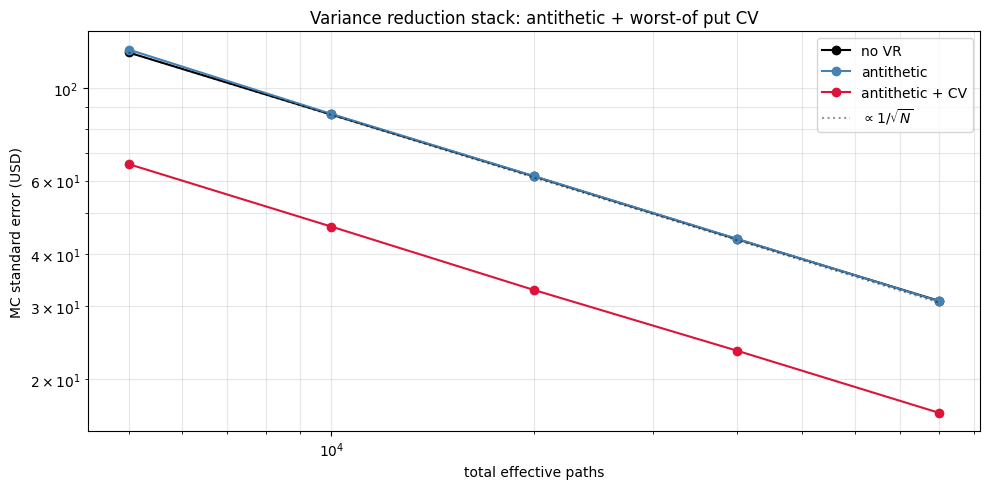

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(vr_df['n_total'], vr_df['no_VR'], 'o-', color='black', label='no VR')
ax.loglog(vr_df['n_total'], vr_df['antithetic'], 'o-', color='steelblue', label='antithetic')
ax.loglog(vr_df['n_total'], vr_df['anti + CV'], 'o-', color='crimson', label='antithetic + CV')
# Reference: 1/sqrt(N) lines anchored to the leftmost no-VR point.
ns_arr = vr_df['n_total'].to_numpy(dtype=float)
anchor = vr_df['no_VR'].iloc[0]
ax.loglog(ns_arr, anchor * np.sqrt(ns_arr[0] / ns_arr), 'k:', alpha=0.4, label=r'$\propto 1/\sqrt{N}$')
ax.set_xlabel('total effective paths'); ax.set_ylabel('MC standard error (USD)')
ax.set_title('Variance reduction stack: antithetic + worst-of put CV')
ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout(); plt.show()


## 4. Limitations

The model is the textbook one. The things it **doesn't** capture are
deliberately out of scope:

1. **Flat Black-Scholes vol per name.** No smile, no term structure. A
   real desk would re-extract vols at each observation date from the
   listed option chain (Phase 3 already does the implied-vol bootstrap
   for the at-the-money point — calibrating a full surface and feeding
   it into a local-vol or stochastic-vol simulator is the natural next
   project).
2. **Constant correlation matrix.** Correlations drift, particularly in
   stress — a Brownian-correlation or DCC model would change the
   ρ_pair Greeks. The Greeks table reports the sensitivity to this
   assumption; in practice that's the exposure metric the desk hedges.
3. **European KI only on the PDE side.** The MC pricer supports
   continuous-KI monitoring (`continuous_ki=True`); the 1D PDE engine
   does not — implementing it would require an absorbing-boundary
   condition along the strike between observation dates. The
   JT-spec'd structure is European KI; the gap is documented in
   METHODOLOGY §4.
4. **Bump-Γ noise.** As the Δ-vs-spot plot shows, MC Γ near the
   barriers is structurally noisy. Real desks deploy
   smoothed-payoff variants (e.g. replace the autocall indicator with a
   tight sigmoid centred at the barrier) for clean Γ — outside the
   scope of this repo's "honest-MC" goal but on the to-do list for any
   production use.
5. **Hard-coded coupon barrier mode.** `coupon_barrier=None` (flat
   coupon every period until autocall) is the JT default; the
   conditional-coupon variant is tested but not the headline.

None of these are reasons to distrust the price *for this product spec
under these assumptions* — the cross-validation against the PDE is the
direct evidence the engines are wired up correctly. They are reasons
the desk would, in a live setting, layer additional model risk on top.